In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('NABIL.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
data = df[['Close']]
data

,Close
Date,
2011-03-20,1170.0
2011-03-24,1153.0
2011-03-25,1174.0
2011-03-27,1147.0
2011-03-28,1132.0
...,...
2024-12-01,536.0
2024-12-02,534.0
2024-12-03,532.0


In [3]:
start_date = data.index.min()
end_date = data.index.max()
tomorrow = end_date + datetime.timedelta(days = 1)
prices = data.loc[start_date:end_date, 'Close']
prices



Date
2011-03-20    1170.0
2011-03-24    1153.0
2011-03-25    1174.0
2011-03-27    1147.0
2011-03-28    1132.0
               ...  
2024-12-01     536.0
2024-12-02     534.0
2024-12-03     532.0
2024-12-04     530.0
2024-12-05     525.0
Name: Close, Length: 3125, dtype: float64

In [4]:
returns = prices.pct_change().dropna()
returns

Date
2011-03-24   -0.014530
2011-03-25    0.018213
2011-03-27   -0.022998
2011-03-28   -0.013078
2011-03-29   -0.030919
                ...   
2024-12-01   -0.007407
2024-12-02   -0.003731
2024-12-03   -0.003745
2024-12-04   -0.003759
2024-12-05   -0.009434
Name: Close, Length: 3124, dtype: float64

Text(0.5, 1.0, 'Stock Prices of NABIL')

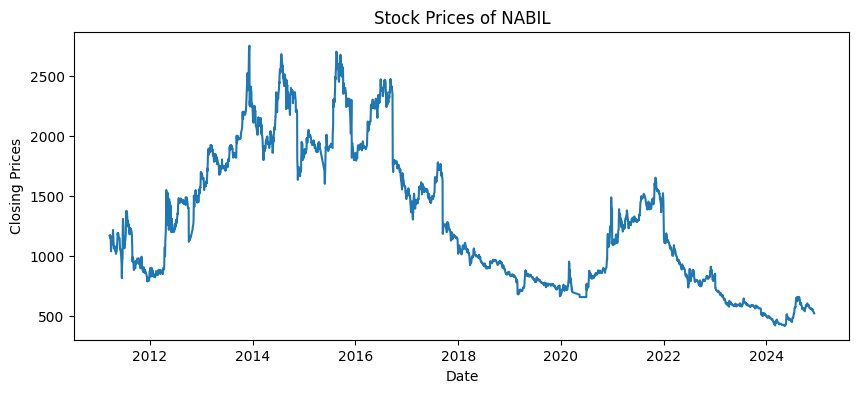

In [5]:
plt.figure(figsize=(10,4))
plt.plot(prices)
plt.ylabel("Closing Prices")
plt.xlabel("Date")
plt.title('Stock Prices of NABIL')

Text(0.5, 1.0, 'Returns of NABIL')

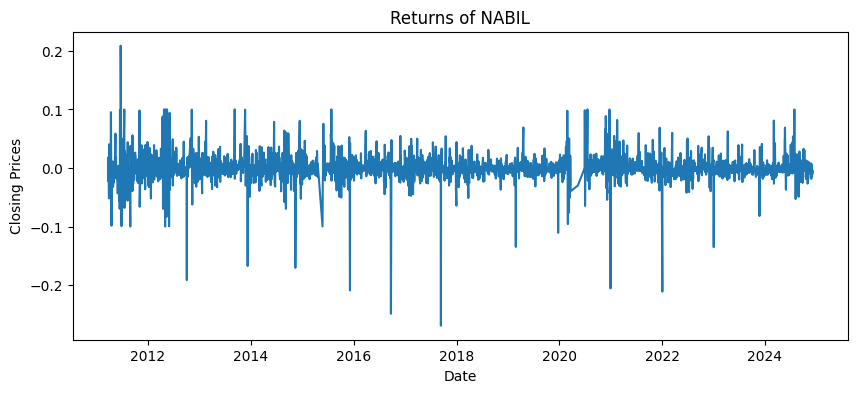

In [6]:
plt.figure(figsize=(10,4))
plt.plot(returns)
plt.ylabel("Closing Prices")
plt.xlabel("Date")
plt.title('Returns of NABIL')

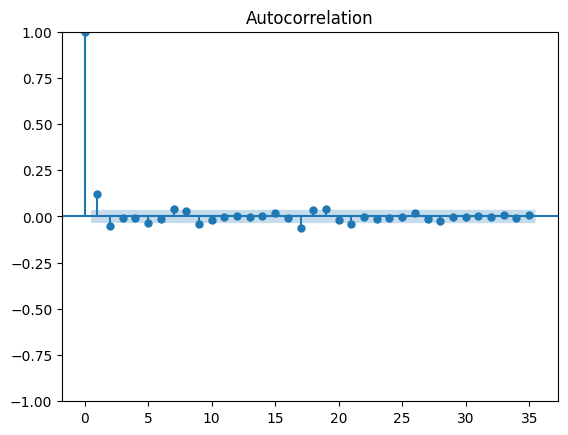

In [7]:
plot_acf(returns)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

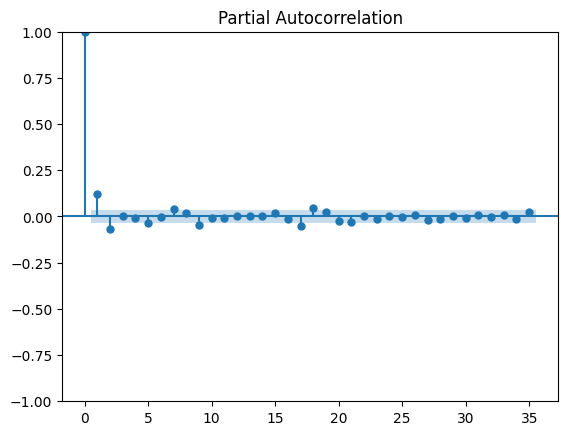

In [8]:
plot_pacf(returns, method='ywm')
plt.show

In [9]:
model = ARIMA(prices, order=(7,0,6))
fitted = model.fit()
print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 3125
Model:                 ARIMA(7, 0, 6)   Log Likelihood              -15526.265
Date:                Sun, 23 Feb 2025   AIC                          31082.529
Time:                        15:48:35   BIC                          31173.237
Sample:                             0   HQIC                         31115.089
                               - 3125                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1283.2573    630.759      2.034      0.042      46.993    2519.522
ar.L1          0.2188      0.199      1.099      0.272      -0.171       0.609
ar.L2          0.3323      0.199      1.668      0.0

In [10]:
next_day_price = fitted.forecast(100, alpha= 0.05)
print(next_day_price)

3125    526.252320
3126    527.812097
3127    528.623906
3128    529.974886
3129    530.902015
           ...    
3220    623.200656
3221    624.149531
3222    625.098011
3223    626.044617
3224    626.989919
Name: predicted_mean, Length: 100, dtype: float64


In [11]:
predicted_price = next_day_price.values[0]
print(f"The predicted price for {tomorrow} tomorrow:", predicted_price)

The predicted price for 2024-12-06 00:00:00 tomorrow: 526.2523195937871


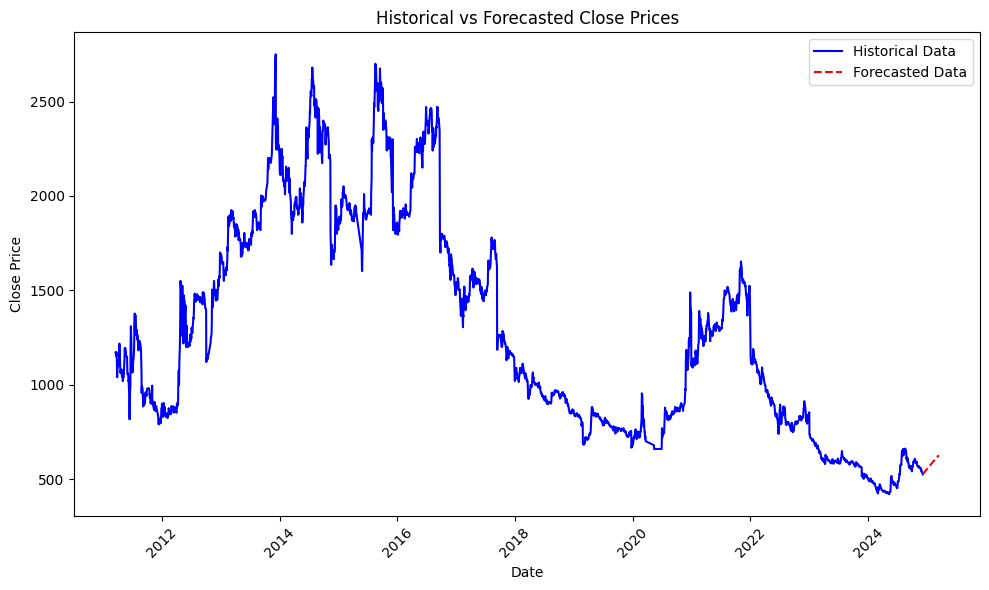

,Close
Date,
2024-12-06,526.252320
2024-12-07,527.812097
2024-12-08,528.623906
2024-12-09,529.974886
2024-12-10,530.902015
...,...
2025-03-11,623.200656
2025-03-12,624.149531
2025-03-13,625.098011


In [12]:
future_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=100, freq='D')

# Create a DataFrame for the future forecasted prices
forecast_df = pd.DataFrame({'Date': future_dates, 'Close': next_day_price})
forecast_df.set_index('Date', inplace=True)

# Plot historical data and forecasted data
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Close'], label='Historical Data', color='blue')
plt.plot(forecast_df.index, forecast_df['Close'], label='Forecasted Data', color='red', linestyle='--')

# Add labels and title
plt.title('Historical vs Forecasted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()

# Show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
forecast_df


In [13]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Assuming 'y_true' is the actual values from the test set and 'y_pred' is the predicted values from your ARIMA model
y_true = test_data['Close']  # Actual values from the test set
y_pred = arima_model.predict(start=test_data.index[0], end=test_data.index[-1])  # Predictions

# Calculate MSE
mse = mean_squared_error(y_true, y_pred)

# Print the MSE value
print(f"Mean Squared Error (MSE): {mse}")


NameError: name 'test_data' is not defined